In [ ]:
# 08 — The Rally as an Absorbing Markov Chain (SQ5)

Models a rally as a sequence of tactical states rather than independent shots.
Each state is a stroke type combined with a direction pattern. Winners and
errors are absorbing states: once reached, the rally stops.

Two quantities are computed from the transition matrix:
- expected number of shots remaining from each state
- probability that the player in that state eventually wins the point

Neither can be obtained from the classification model in notebook 06.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

shots = pd.read_parquet(PROCESSED / "shots_eda.parquet")
print("Shots:", shots.shape)

Shots: (5313675, 17)


In [2]:
# The state space must be small enough for every transition to be estimated
# from enough observations. Eighteen shot types would give far too many
# states, so strokes are grouped into four families.
NET_SHOTS = {"forehand_volley", "backhand_volley", "overhead",
             "backhand_overhead", "forehand_halfvolley", "backhand_halfvolley",
             "forehand_swingvolley", "backhand_swingvolley"}

STROKE_GROUPS = {"forehand": "forehand", "backhand": "backhand",
                 "forehand_slice": "slice", "backhand_slice": "slice"}

def stroke_group(shot_type):
    if shot_type in STROKE_GROUPS:
        return STROKE_GROUPS[shot_type]
    if shot_type in NET_SHOTS:
        return "net"
    return "other"

shots["stroke_group"] = shots["shot_type"].map(stroke_group)

# Rare strokes (drop shots, lobs, trick shots) are removed rather than merged,
# because grouping them with normal strokes would blur the state meaning.
chain_data = shots[shots["stroke_group"] != "other"].copy()

# The return is its own state: it has no preceding rally shot, so it cannot
# have a direction pattern, and it is played under different constraints.
chain_data["state"] = np.where(
    chain_data["shot_number"] == 2,
    "return",
    chain_data["stroke_group"] + "_" +
    chain_data["direction_pattern"].fillna("middle"))

print("States:", chain_data["state"].nunique())
print(chain_data["state"].value_counts())

States: 13
state
return                    1216483
forehand_middle           1150356
backhand_middle            725670
backhand_cross_court       495146
forehand_cross_court       473419
forehand_down_the_line     290049
slice_middle               212379
backhand_down_the_line     188564
slice_cross_court          146028
net_middle                 116361
slice_down_the_line         70080
net_down_the_line           37528
net_cross_court             36773
Name: count, dtype: int64


In [6]:
chain_data = chain_data.sort_values(["match_id", "Pt", "shot_number"])
chain_data["next_state"] = chain_data.groupby(["match_id", "Pt"],
                                              observed=True)["state"].shift(-1)
chain_data.loc[chain_data["shot_outcome"] != "in_play", "next_state"] = None

# Some rallies continued into a stroke type we removed from the state space
# (drop shots, lobs, trick shots). Those shots are marked in_play but have no
# successor in the filtered data, so they are censored: we know the rally went
# on, but not where. They are excluded rather than counted as endings, which
# would wrongly inflate the absorption probabilities.
observed = (chain_data["shot_outcome"] != "in_play") | chain_data["next_state"].notna()

print(f"Censored shots removed: {(~observed).sum():,} "
      f"({100 * (~observed).mean():.2f}%)")

chain_data = chain_data[observed]

states = sorted(chain_data["state"].unique())
state_index = {s: i for i, s in enumerate(states)}
n_states = len(states)

Q = np.zeros((n_states, n_states))
p_win = np.zeros(n_states)
p_lose = np.zeros(n_states)

for state, group in chain_data.groupby("state", observed=True):
    i = state_index[state]
    total = len(group)

    p_win[i] = (group["shot_outcome"] == "winner").sum() / total
    p_lose[i] = group["shot_outcome"].isin(
        ["unforced_error", "forced_error"]).sum() / total

    for target, count in group["next_state"].dropna().value_counts().items():
        if target in state_index:
            Q[i, state_index[target]] = count / total

print("Transition matrix:", Q.shape)

Censored shots removed: 49,753 (0.96%)
Transition matrix: (13, 13)


In [7]:
# Row sums must be 1: from any state the rally either continues, ends in a
# winner, or ends in an error. A small residual can remain if a transition
# target fell below the state space, so the tolerance allows 0.5%.
row_sums = Q.sum(axis=1) + p_win + p_lose
print("Row sums min/max:", row_sums.min().round(6), row_sums.max().round(6))

if not np.allclose(row_sums, 1.0, atol=5e-3):
    print("\nRows furthest from 1:")
    print(pd.Series(row_sums, index=states).sort_values().head(5).round(4))
    raise AssertionError("Transition matrix does not sum to 1")

# Normalise away the remaining rounding residual so the linear algebra is exact.
scale = row_sums.reshape(-1, 1)
Q = Q / scale
p_win = p_win / row_sums
p_lose = p_lose / row_sums

print("Matrix is valid.")

Row sums min/max: 1.0 1.0
Matrix is valid.


In [8]:
I = np.eye(n_states)

# Expected remaining shots. The fundamental matrix N = (I - Q)^-1 gives the
# expected number of visits to each state before absorption, so N multiplied
# by a vector of ones gives the expected number of steps remaining.
expected_shots = np.linalg.solve(I - Q, np.ones(n_states))

# Probability of eventually winning the point. This needs care, because the
# players alternate: a transition hands the rally to the opponent. If w(s) is
# the chance that the player in state s wins, then
#     w(s) = p_win(s) + sum_t Q(s,t) * (1 - w(t))
# because reaching state t means the OPPONENT is now hitting. Rearranged:
#     (I + Q) w = p_win + Q * 1
win_probability = np.linalg.solve(I + Q, p_win + Q @ np.ones(n_states))

markov = pd.DataFrame({
    "state": states,
    "p_win_immediately": p_win,
    "p_lose_immediately": p_lose,
    "expected_shots_remaining": expected_shots,
    "p_win_point": win_probability,
}).sort_values("p_win_point", ascending=False)

print(markov.round(3).to_string(index=False))

                 state  p_win_immediately  p_lose_immediately  expected_shots_remaining  p_win_point
       net_cross_court              0.487               0.169                     2.288        0.665
            net_middle              0.408               0.202                     2.519        0.605
     net_down_the_line              0.427               0.226                     2.268        0.598
       forehand_middle              0.069               0.140                     4.423        0.485
  forehand_cross_court              0.058               0.140                     4.324        0.481
  backhand_cross_court              0.032               0.120                     4.595        0.481
forehand_down_the_line              0.129               0.222                     3.737        0.470
       backhand_middle              0.029               0.134                     4.651        0.467
backhand_down_the_line              0.140               0.259                     3.444    

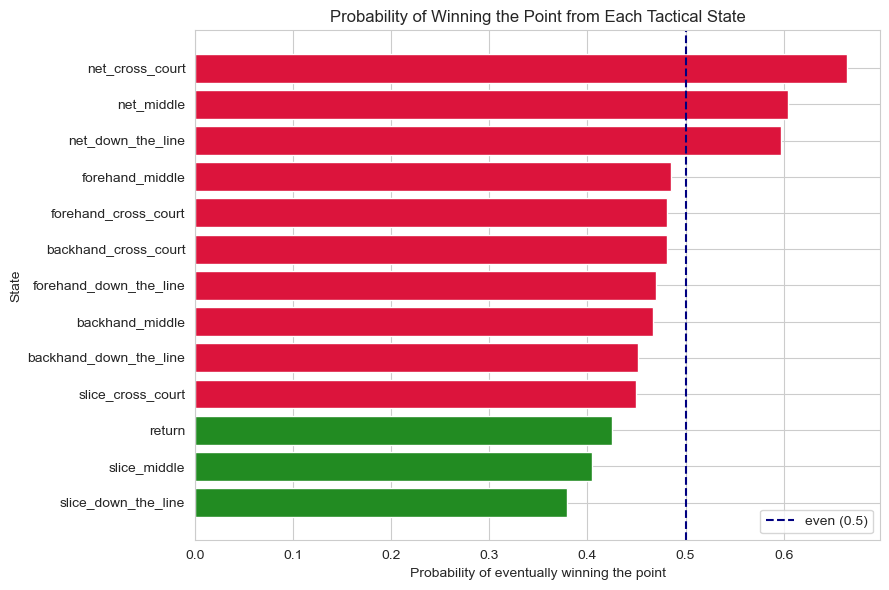

In [9]:
# Which tactical positions are actually worth being in.
plt.figure(figsize=(9, 6))
colours = ["forestgreen" if p > 0.5 else "crimson"
           for p in markov["p_win_point"]]
plt.barh(markov["state"][::-1], markov["p_win_point"][::-1], color=colours)
plt.axvline(0.5, color="navy", linestyle="--", label="even (0.5)")
plt.title("Probability of Winning the Point from Each Tactical State")
plt.xlabel("Probability of eventually winning the point")
plt.ylabel("State")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "markov_win_probability.png", dpi=150)
plt.show()

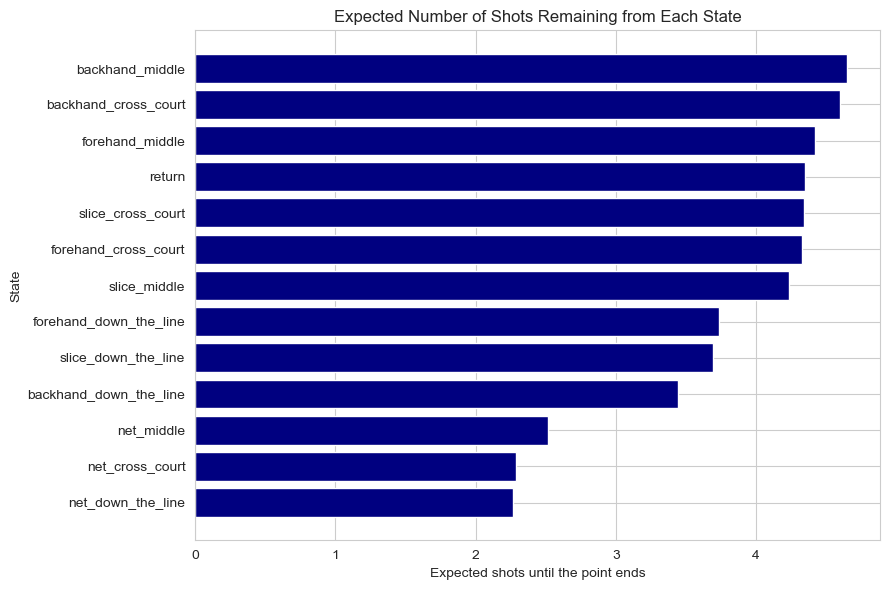

In [10]:
plt.figure(figsize=(9, 6))
ordered = markov.sort_values("expected_shots_remaining")
plt.barh(ordered["state"], ordered["expected_shots_remaining"], color="navy")
plt.title("Expected Number of Shots Remaining from Each State")
plt.xlabel("Expected shots until the point ends")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(FIGURES / "markov_expected_length.png", dpi=150)
plt.show()

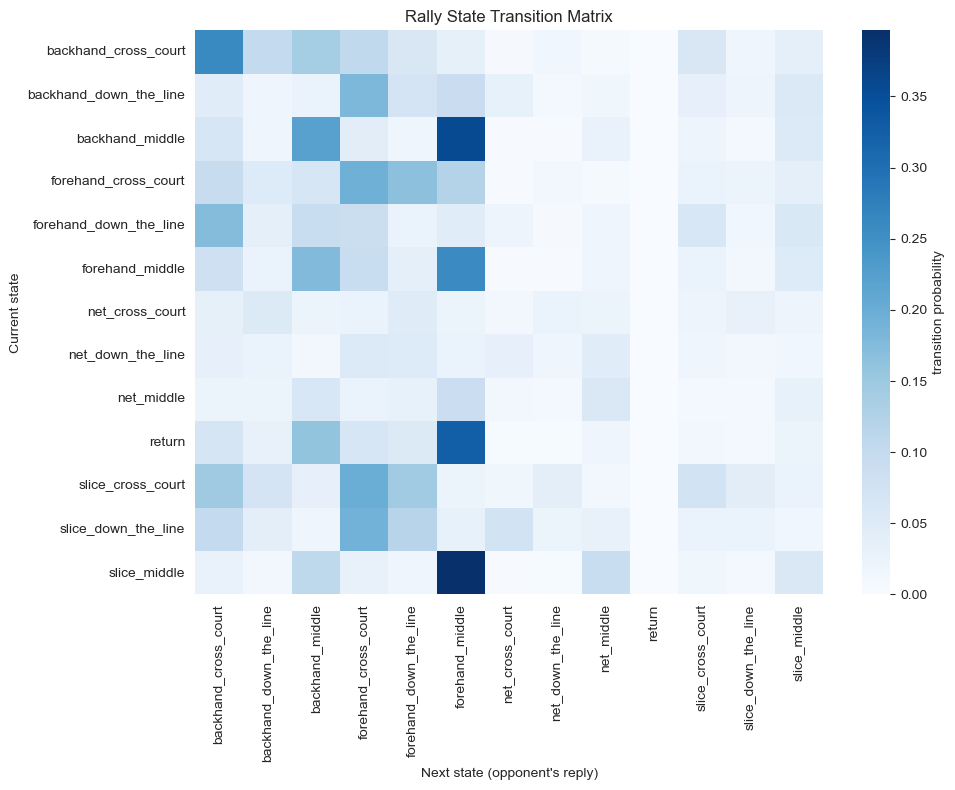

In [11]:
# How play flows between states. Rows are the current shot, columns the reply.
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(Q, index=states, columns=states),
            cmap="Blues", annot=False, cbar_kws={"label": "transition probability"})
plt.title("Rally State Transition Matrix")
plt.xlabel("Next state (opponent's reply)")
plt.ylabel("Current state")
plt.tight_layout()
plt.savefig(FIGURES / "markov_transition_matrix.png", dpi=150)
plt.show()

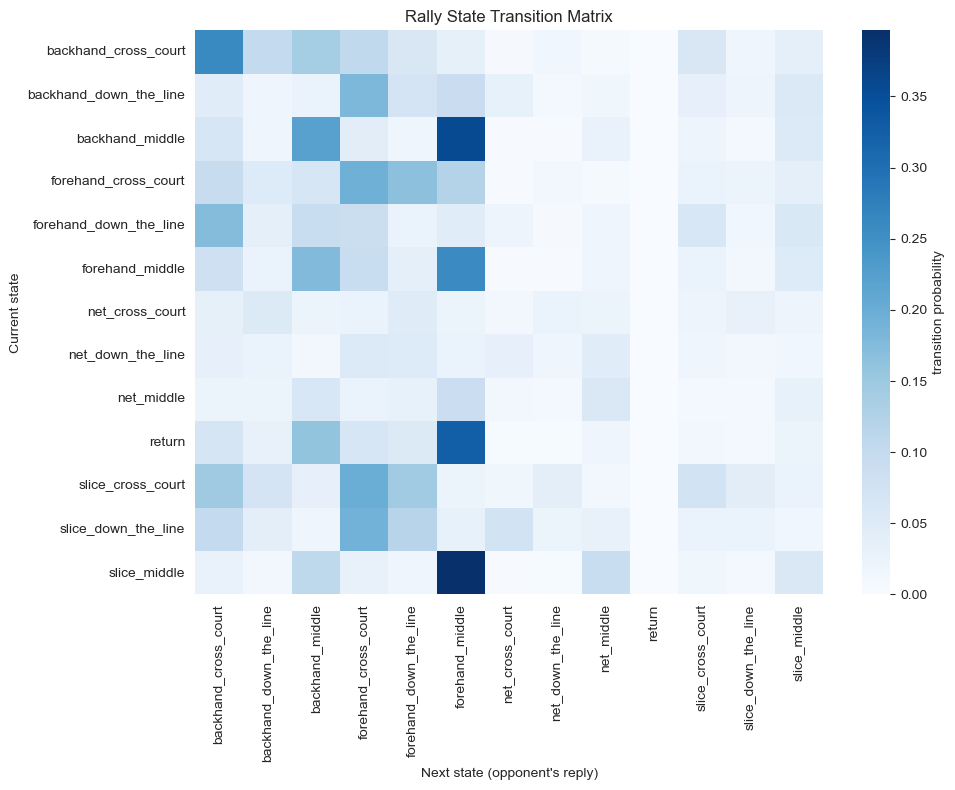

In [12]:
# How play flows between states. Rows are the current shot, columns the reply.
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(Q, index=states, columns=states),
            cmap="Blues", annot=False, cbar_kws={"label": "transition probability"})
plt.title("Rally State Transition Matrix")
plt.xlabel("Next state (opponent's reply)")
plt.ylabel("Current state")
plt.tight_layout()
plt.savefig(FIGURES / "markov_transition_matrix.png", dpi=150)
plt.show()

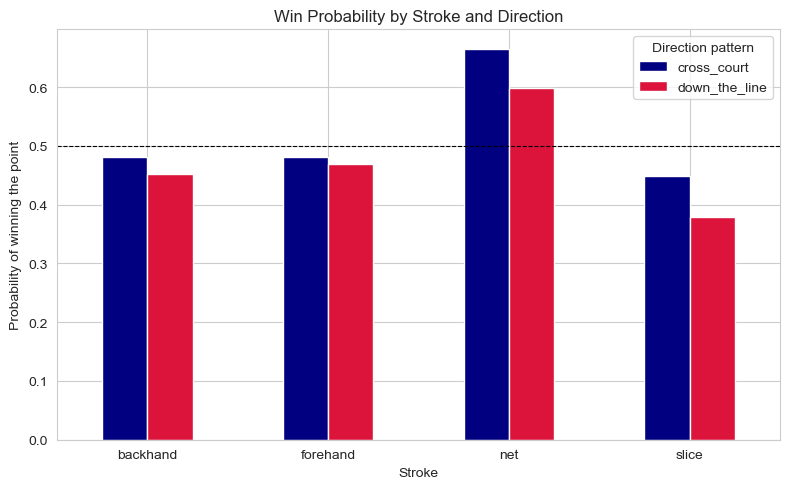

pattern   cross_court  down_the_line  difference
stroke                                          
backhand       0.4808         0.4517     -0.0291
forehand       0.4812         0.4699     -0.0113
net            0.6650         0.5978     -0.0672
slice          0.4491         0.3790     -0.0701


In [13]:
# Independent check. The counterfactual analysis in notebook 07 concluded that
# down-the-line is not more valuable than cross-court once context is fixed.
# The Markov chain uses completely different mathematics, so agreement between
# them is meaningful evidence rather than repetition.
comparison = markov[markov["state"].str.contains("cross_court|down_the_line")].copy()
comparison["stroke"] = comparison["state"].str.split("_").str[0]
comparison["pattern"] = np.where(
    comparison["state"].str.contains("cross_court"), "cross_court", "down_the_line")

pivot = comparison.pivot(index="stroke", columns="pattern", values="p_win_point")
pivot["difference"] = pivot["down_the_line"] - pivot["cross_court"]

plt.figure(figsize=(8, 5))
pivot[["cross_court", "down_the_line"]].plot(
    kind="bar", color=["navy", "crimson"], ax=plt.gca())
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.title("Win Probability by Stroke and Direction")
plt.xlabel("Stroke")
plt.ylabel("Probability of winning the point")
plt.legend(title="Direction pattern")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES / "markov_direction_comparison.png", dpi=150)
plt.show()

print(pivot.round(4).to_string())

In [14]:
markov.to_csv(FIGURES / "markov_results.csv", index=False)
pd.DataFrame(Q, index=states, columns=states).to_csv(
    FIGURES / "markov_transition_matrix.csv")
print("Saved.")

Saved.
